# 1D Langevian Equation for Brownian Motion 

This notebook contains the computational implementation of a particle undergoing [Brownian Motion](https://en.wikipedia.org/wiki/Brownian_motion). Here we integrate the [Langevin Equations](https://en.wikipedia.org/wiki/Langevin_equation) using the [Leapfrog](https://en.wikipedia.org/wiki/Leapfrog_integration) integration method. For this, we develop a custom single-particle integrator with and without an external potential. Running the simulation with different random seeds gives different realisations of the stochastic process. Analysing these multiple realisations yields the coefficients of the Fokker-Planck equation and $P(x,t)$ at a given time stamp.

The Langevin equation for a particle executing Brownian motion is given as:
$$ \frac{d \mathbf{r}}{dt} = \mathbf{v} \tag{1}$$

$$ \frac{d \mathbf{v}}{dt} = - \frac{\gamma}{m}\mathbf{v} - \frac{\nabla U(\mathbf{r})}{m} + \sqrt{2D} \xi(t) \tag{2}$$

Where $D$ is the noise strength and is given by $D = \frac{k_B T \gamma}{m^2}$, the Stokes friction coefficient is $\gamma$, the space-dependent potential is $U(r)$ and the source of the stochasticity obeys $\braket{\xi (t)} = 0$ , $\braket{\xi_i(t)\xi_j(t')} = \delta (t - t')$ and $i,j = x,y,z$ 

Based on Eqn. $(1)$ and $(2)$ we can write the leapfrog integration steps as:
$$ v_{i + 1/2} =  v_i - \frac{\gamma}{2m}v_i \Delta t - \frac{\nabla U(x_i)}{2m} \Delta t + \sqrt{D \Delta t} \xi^{(1)}(t)  \tag{3}$$
Where, $\xi (t)$ is sampled from a normal distribution

$$ x_{i+1} = x_i + v_{i+1/2} \Delta t \tag{4}$$

$$ v_{i + 1} =  v_{i+1/2} - \frac{\gamma}{2m}v_{i+1/2}  \Delta t - \frac{\nabla U(x_{i+1})}{2m} \Delta t + \sqrt{D \Delta t} \xi^{(2)}(t)  \tag{5}$$

For calculating the gradient of the spatial potential, we use the Central Difference Method.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from zero_potential_lf import integrate_langevin_leapfrog
from complete_lf import integrate_langevin_leapfrog_with_potential

`integrate_langevin_leapfrog` uses Eqn. (3), (4) and (5) to integrate the langevin equation to give the particle trajectory.

Text(0, 0.5, 'position')

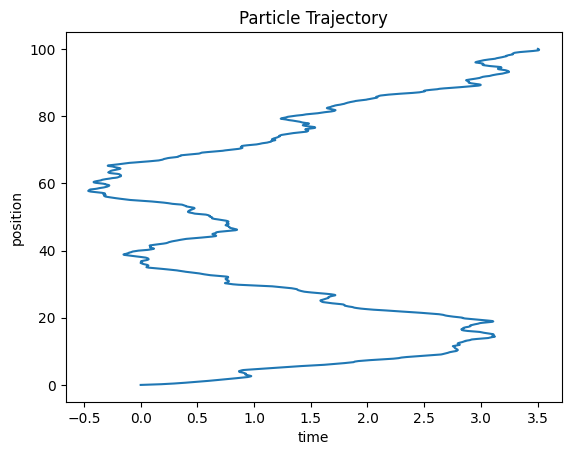

In [2]:
time, x, v = integrate_langevin_leapfrog(
    x0=0.0,                #Initial Position
    v0=1.0,                #Initial Velocity
    n_steps=10000,         #Number of Integration Steps
    dt=0.01,               #Integration Time Step
    g=1.0,                 #Coefficient of Stokes Drag
    m=1.0,                 #Particle Mass
    D=0.1,                 #Strength of Noise
    seed=42                #Random seed
)

plt.plot(x, time)
plt.title("Particle Trajectory")
plt.xlabel("time")
plt.ylabel("position")

`integrate_langevin_leapfrog_with_potential` includes the spatial potential in the integration.

Text(0, 0.5, 'position')

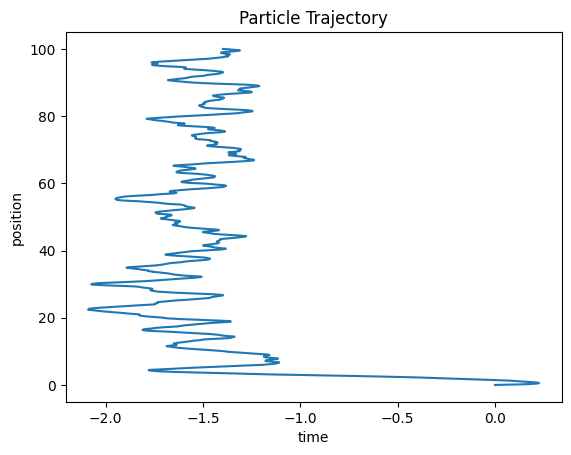

In [3]:
time, x, v = integrate_langevin_leapfrog_with_potential(
    x0=0.0,
    v0=1.0,
    n_steps=10000,
    dt=0.01,
    g=1.0,
    m=1.0,
    D=0.1,
    U=np.sin,                 #spatial potential
    h=1e-5,                   #small increment for graident calculation
    seed=42
)

plt.plot(x, time)
plt.title("Particle Trajectory")
plt.xlabel("time")
plt.ylabel("position")